# Introduction
We will use this notebook to explore the data initially, before initiating any trading algorithm.

# Import

In [24]:
# Standard library imports
import datetime as dt
import os

# Third party imports
import pandas as pd
import numpy as np

# Data Analysis

In [25]:
df_train = pd.read_csv('df_train.csv')

In [26]:
df_train.head()

,date,symbol,open,close,low,high,volume
0,2010-01-04,ACTS,15.13,14.97,14.84,15.28,5459.882
1,2010-01-04,AMWD,7.00,7.12,6.98,7.14,92067.275
2,2010-01-04,ARV,18.27,18.31,18.12,18.47,38034.257
3,2010-01-04,BBY,3.11,3.11,3.09,3.13,40964.820
4,2010-01-04,BCDM,19.78,19.53,19.41,19.90,3646.991


In [27]:
df_train.tail()

,date,symbol,open,close,low,high,volume
100595,2013-12-31,XTG,20.15,20.00,20.15,20.15,42044.703
100596,2013-12-31,YPN,14.94,14.82,14.94,14.94,29030.106
100597,2013-12-31,YRD,3.40,3.39,3.40,3.40,11778.336
100598,2013-12-31,YVNL,4.25,4.24,4.25,4.25,6431.843
100599,2013-12-31,ZQN,32.01,32.04,32.01,32.01,54319.469


In [28]:
df_train.shape

(100600, 7)

In [29]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100600 entries, 0 to 100599
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    100600 non-null  object 
 1   symbol  100600 non-null  object 
 2   open    100600 non-null  float64
 3   close   100600 non-null  float64
 4   low     100600 non-null  float64
 5   high    100600 non-null  float64
 6   volume  100600 non-null  float64
dtypes: float64(5), object(2)
memory usage: 5.4+ MB


In [30]:
print('Number of unique symbols:', len(df_train['symbol'].unique()))
print('Number of unique dates:', len(df_train['date'].unique()))

Number of unique symbols: 100
Number of unique dates: 1006


In [31]:
df_train.describe()

,open,close,low,high,volume
count,100600.000000,100600.000000,100600.000000,100600.000000,1.006000e+05
mean,20.041719,20.048185,20.041558,20.042048,6.660785e+04
std,18.338207,18.335750,18.338101,18.338469,1.057868e+05
min,1.310000,1.310000,1.310000,1.310000,5.868770e+02
25%,6.690000,6.700000,6.690000,6.690000,1.459317e+04
50%,13.950000,13.970000,13.950000,13.950000,3.323060e+04
75%,27.450000,27.480000,27.450000,27.450000,7.313989e+04
max,139.510000,139.380000,139.510000,139.510000,2.990820e+06


# Signal Analysis: Moving Average & Momentum

This section constructs and evaluates two families of signals on the cross-section of 100 stocks over 2010–2013:
- **Moving Average (MA) signals**: trend-following
- **Momentum signals**: past-return-based, both short- and long-horizon

Each signal is evaluated using:
1. **Information Coefficient (IC)**: Spearman rank correlation between signal and next-day return, per day across stocks
2. **Long-Short Portfolio**: top-quintile long, bottom-quintile short, daily rebalanced

In [32]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.stats import spearmanr, ttest_1samp

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

## Data Preparation

Pivot to wide format (dates × symbols). Compute daily returns and 1-day forward returns.

In [33]:
df_train['date'] = pd.to_datetime(df_train['date'])
df_train = df_train.sort_values(['symbol', 'date']).reset_index(drop=True)

# Wide format: rows = dates, columns = symbols
close  = df_train.pivot(index='date', columns='symbol', values='close')

# Daily simple returns
ret = close.pct_change()

# 1-day forward return
fwd_ret_1d = ret.shift(-1)

print(f"Price matrix shape: {close.shape}")
print(f"Date range: {close.index[0].date()} to {close.index[-1].date()}")
close.head(3)

Price matrix shape: (1006, 100)
Date range: 2010-01-04 to 2013-12-31


symbol,ACTS,AMWD,ARV,BBY,BCDM,BZK,BZQM,CDM,CDRX,CLYQ,...,WYLR,WZB,XBRQ,XFG,XPT,XTG,YPN,YRD,YVNL,ZQN
date,,,,,,,,,,,,,,,,,,,,,
2010-01-04,14.97,7.12,18.31,3.11,19.53,15.14,52.77,13.08,13.34,2.85,...,13.45,6.14,9.68,20.00,61.43,19.58,14.00,5.23,3.02,29.43
2010-01-05,14.85,6.99,18.26,3.09,19.30,15.10,51.60,12.97,13.15,2.81,...,13.33,6.05,9.65,20.02,60.85,19.33,13.82,5.22,3.00,29.36
2010-01-06,14.86,6.84,17.88,3.04,19.00,14.91,50.72,13.05,12.95,2.80,...,13.17,5.95,9.51,19.38,59.63,19.41,13.71,5.14,2.91,28.70


## Signal Construction

### Moving Average Signals

| Signal | Logic | Hypothesis |
|--------|-------|------------|
| MA_Cross(5,20) | SMA5 > SMA20 → +1, else −1 | Short-term trend confirms medium-term |
| Price_vs_MA20  | Close > SMA20 → +1, else −1 | Price above MA = uptrend |

### Momentum Signals

| Signal | Logic | Hypothesis |
|--------|-------|------------|
| Mom_10d | 10-day past return (continuous) | Short-term momentum |
| Mom_20d | 20-day past return | Medium-term momentum |
| Mom_60d | 60-day past return | Longer-horizon trend / potential mean-reversion |

In [34]:
# Moving Average Signals
sma5  = close.rolling(window=5,  min_periods=5).mean()
sma20 = close.rolling(window=20, min_periods=20).mean()
sma60 = close.rolling(window=60, min_periods=60).mean()

# Continuous strength versions (more informative than ±1)
ma_cross_cont = (sma5 - sma20) / sma20        # normalised distance fast vs slow MA
price_ma_cont = (close - sma20) / sma20        # normalised distance price vs MA20

# Binary sign versions (for comparison)
ma_cross_sign = np.sign(sma5 - sma20)          # +1 / -1
price_ma_sign = np.sign(close - sma20)

# Momentum Signals
mom10 = close.pct_change(10)   # short-term
mom20 = close.pct_change(20)   # medium-term
mom60 = close.pct_change(60)   # longer-horizon

signals = {
    'MA_Cross(5,20)':   ma_cross_cont,
    'Price_vs_MA20':    price_ma_cont,
    'Momentum_10d':     mom10,
    'Momentum_20d':     mom20,
    'Momentum_60d':     mom60,
}
print("Signals constructed:", list(signals.keys()))

Signals constructed: ['MA_Cross(5,20)', 'Price_vs_MA20', 'Momentum_10d', 'Momentum_20d', 'Momentum_60d']


## Signal Evaluation — Information Coefficient (IC)

For each trading day $t$, compute the Spearman rank correlation between signal $s_{i,t}$ and the next-day return $r_{i,t+1}$ across all stocks $i$:

$$\text{IC}_t = \text{Spearman}\left(s_{i,t},\; r_{i,t+1}\right)_{i=1}^{100}$$

Key metrics:
- **Mean IC**: average predictive power. |IC| > 0.02 is generally considered useful in practice.
- **IC IR** (= Mean IC / Std IC × √252): annualised information ratio of the IC series.
- **t-stat**: tests H₀: Mean IC = 0. |t| > 2 ⟹ statistically significant.

In [35]:
def compute_daily_ic(signal, fwd_ret):
    ic_series = {}
    for date in signal.index.intersection(fwd_ret.index):
        s = signal.loc[date].dropna()
        f = fwd_ret.loc[date].dropna()
        common = s.index.intersection(f.index)
        if len(common) < 10:
            continue
        ic, _ = spearmanr(s[common], f[common])
        if not np.isnan(ic):
            ic_series[date] = ic
    return pd.Series(ic_series)


# Compute IC for every signal
ic_results = {}
for name, sig in signals.items():
    ic = compute_daily_ic(sig, fwd_ret_1d)
    t_stat, _ = ttest_1samp(ic.dropna(), 0)
    ic_results[name] = {
        'Mean IC':  ic.mean(),
        'IC Std':   ic.std(),
        'IC IR':    ic.mean() / ic.std() * np.sqrt(252),
        't-stat':   t_stat,
        'N days':   len(ic),
    }

ic_df = pd.DataFrame(ic_results).T.round(4)
print(ic_df.to_string())

                Mean IC  IC Std   IC IR  t-stat  N days
MA_Cross(5,20)   0.0246  0.1779  2.1922  4.3363   986.0
Price_vs_MA20    0.0215  0.1820  1.8711  3.7011   986.0
Momentum_10d     0.0268  0.1781  2.3919  4.7528   995.0
Momentum_20d     0.0008  0.1796  0.0739  0.1461   985.0
Momentum_60d    -0.0373  0.1582 -3.7405 -7.2434   945.0


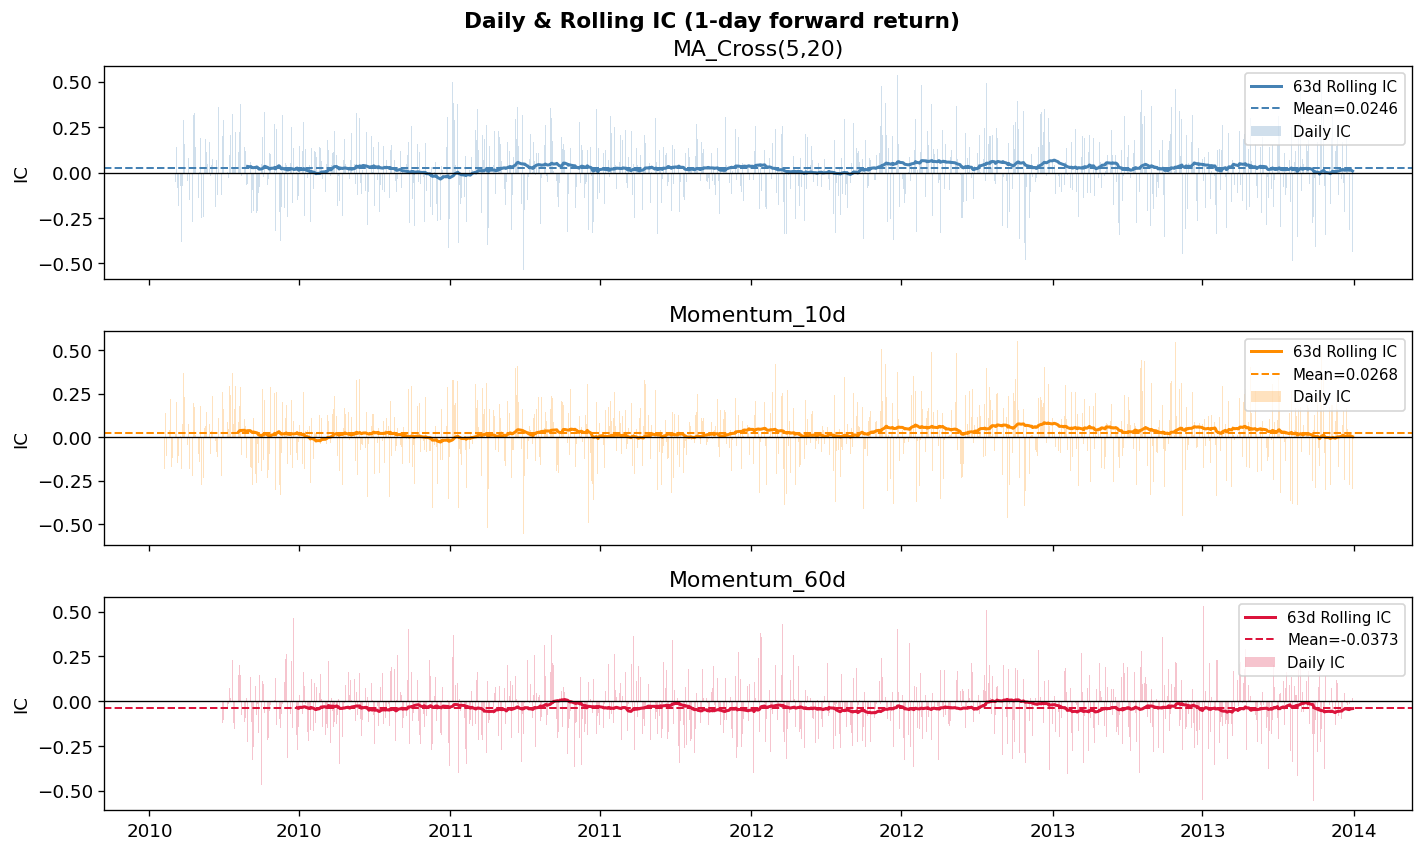

In [36]:
key_signals = ['MA_Cross(5,20)', 'Momentum_10d', 'Momentum_60d']
key_colors  = ['steelblue', 'darkorange', 'crimson']

fig, axes = plt.subplots(len(key_signals), 1, figsize=(12, 7), sharex=True)

for ax, name, color in zip(axes, key_signals, key_colors):
    ic = compute_daily_ic(signals[name], fwd_ret_1d)
    roll_ic = ic.rolling(63).mean()
    ax.bar(ic.index, ic.values, color=color, alpha=0.25, width=1, label='Daily IC')
    ax.plot(roll_ic.index, roll_ic.values, color=color, lw=1.8, label='63d Rolling IC')
    ax.axhline(0, color='black', lw=0.8)
    ax.axhline(ic.mean(), color=color, lw=1.2, ls='--', label=f'Mean={ic.mean():.4f}')
    ax.set_ylabel('IC')
    ax.set_title(name)
    ax.legend(fontsize=9, loc='upper right')

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.suptitle('Daily & Rolling IC (1-day forward return)', y=1.01, fontsize=13, fontweight='bold')
plt.show()

## Long-Short Portfolio Backtest

Each day, sort all 100 stocks by signal value:
- **Long** top quintile (20 stocks)
- **Short** bottom quintile (20 stocks)
- Equal-weight within each leg; rebalance daily

P&L = (average long return) − (average short return). No transaction costs assumed.

In [37]:
def long_short_portfolio(signal, fwd_ret, q=0.2):
    records = []
    for date in signal.index.intersection(fwd_ret.index):
        s = signal.loc[date].dropna()
        f = fwd_ret.loc[date].dropna()
        common = s.index.intersection(f.index)
        if len(common) < 10:
            continue
        n = max(1, int(len(common) * q))
        s_c, f_c = s[common], f[common]
        long_ret  = f_c[s_c.nlargest(n).index].mean()
        short_ret = f_c[s_c.nsmallest(n).index].mean()
        records.append({'date': date, 'ls': long_ret - short_ret,
                        'long': long_ret, 'short': short_ret})
    return pd.DataFrame(records).set_index('date')


# Run backtest for all signals
bt_results = {}
summary_rows = []
for name, sig in signals.items():
    pf = long_short_portfolio(sig, fwd_ret_1d)
    ls = pf['ls'].dropna()
    ann_ret  = ls.mean() * 252
    ann_vol  = ls.std()  * np.sqrt(252)
    sharpe   = ann_ret / ann_vol if ann_vol > 0 else np.nan
    cum      = (1 + ls).cumprod()
    max_dd   = (cum / cum.cummax() - 1).min()
    win_rate = (ls > 0).mean()
    bt_results[name] = pf
    summary_rows.append({
        'Signal':       name,
        'Ann. Return':  f"{ann_ret*100:.2f}%",
        'Ann. Vol':     f"{ann_vol*100:.2f}%",
        'Sharpe':       round(sharpe, 3),
        'Max Drawdown': f"{max_dd*100:.2f}%",
        'Win Rate':     f"{win_rate*100:.2f}%",
    })

summary_df = pd.DataFrame(summary_rows).set_index('Signal')
print(summary_df.to_string())

               Ann. Return Ann. Vol  Sharpe Max Drawdown Win Rate
Signal                                                           
MA_Cross(5,20)      13.43%   14.60%   0.920      -16.94%   53.25%
Price_vs_MA20        6.78%   15.04%   0.451      -27.55%   52.13%
Momentum_10d        13.10%   14.75%   0.888      -18.45%   53.17%
Momentum_20d        -9.33%   14.53%  -0.642      -43.25%   48.63%
Momentum_60d       -46.02%   13.70%  -3.358      -82.81%   39.26%


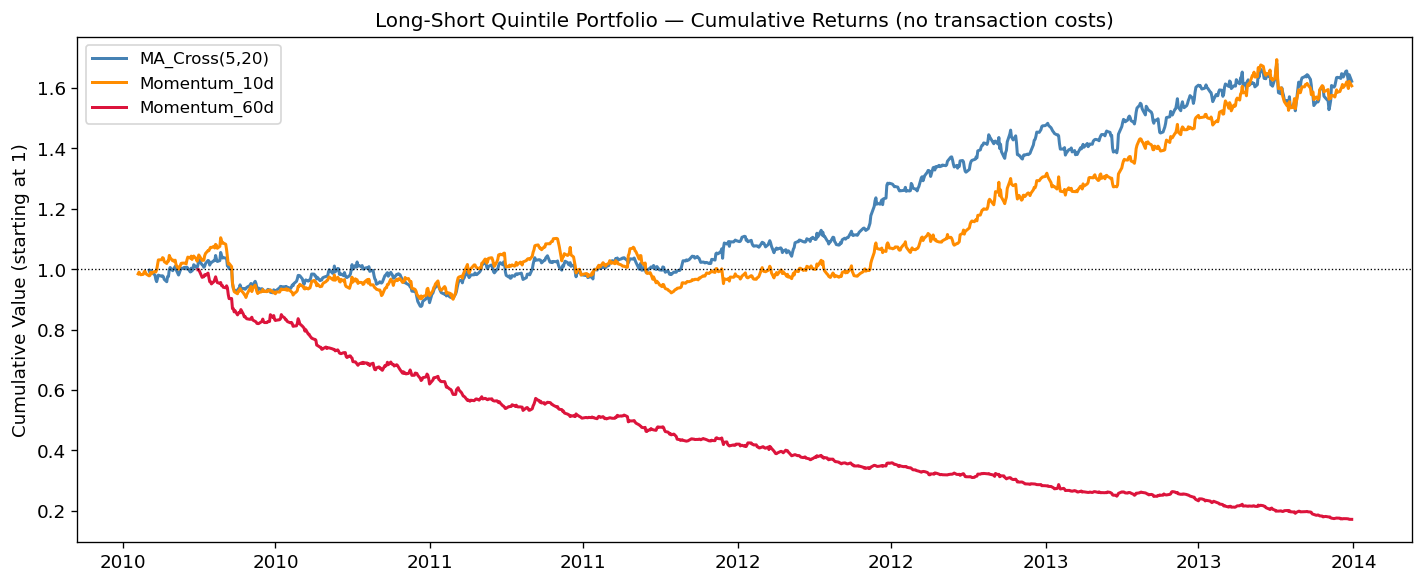

In [38]:
# Plot: Cumulative L-S portfolio returns
fig, ax = plt.subplots(figsize=(12, 5))

plot_signals = {
    'MA_Cross(5,20)': ('steelblue', '-'),
    'Momentum_10d':   ('darkorange', '-'),
    'Momentum_60d':   ('crimson', '-'),   # negative = mean-reversion story
}

for name, (color, ls) in plot_signals.items():
    ls_series = bt_results[name]['ls'].dropna()
    cum = (1 + ls_series).cumprod()
    ax.plot(cum.index, cum.values, color=color, lw=1.8, ls=ls, label=name)

ax.axhline(1, color='black', lw=0.8, ls=':')
ax.set_ylabel('Cumulative Value (starting at 1)')
ax.set_title('Long-Short Quintile Portfolio — Cumulative Returns (no transaction costs)', fontsize=12)
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

## Signal Decay Analysis

How far into the future does each signal predict returns?
Compute IC at forecast horizons h = 1, 2, 3, 5, 10, 20 trading days.

- **Decaying IC** → signal information is consumed quickly (momentum / MA trends).
- **Growing IC** → signal builds up over time (mean-reversion effects strengthen).

Mean IC at different forecast horizons (compound returns):
       MA_Cross(5,20)  Momentum_10d  Momentum_60d
h=1d           0.0246        0.0268       -0.0373
h=2d           0.0300        0.0413       -0.0528
h=3d           0.0314        0.0510       -0.0660
h=5d           0.0281        0.0576       -0.0855
h=10d         -0.0093        0.0362       -0.1278
h=20d         -0.1097       -0.0555       -0.1933


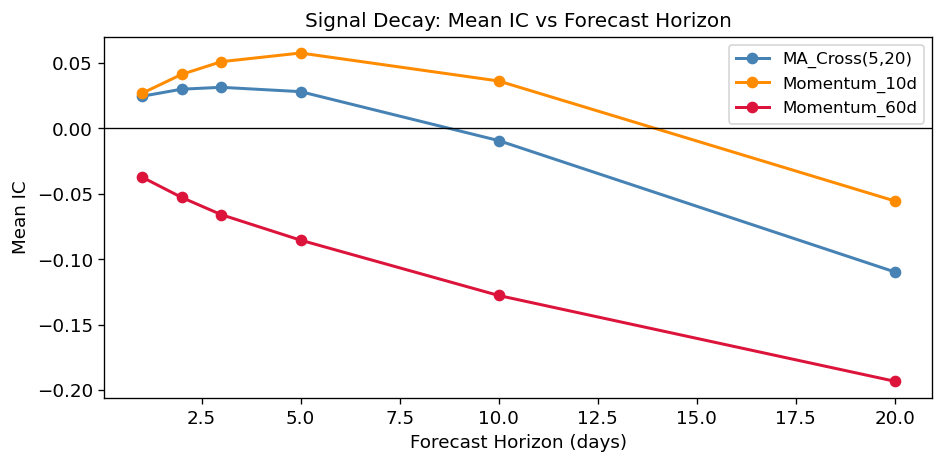

In [39]:
horizons = [1, 2, 3, 5, 10, 20]
decay_signals = {
    'MA_Cross(5,20)': ma_cross_cont,
    'Momentum_10d':   mom10,
    'Momentum_60d':   mom60,   # negative IC = mean-reversion story
}

decay_data = {}
for name, sig in decay_signals.items():
    row = []
    for h in horizons:
        # Compound h-day forward return: avoids additive approximation error
        fwd_h = close.shift(-h) / close - 1
        ic_h  = compute_daily_ic(sig, fwd_h)
        row.append(ic_h.mean())
    decay_data[name] = row

decay_df = pd.DataFrame(decay_data, index=[f'h={h}d' for h in horizons])
print("Mean IC at different forecast horizons (compound returns):")
print(decay_df.round(4).to_string())

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['steelblue', 'darkorange', 'crimson']
for (name, vals), color in zip(decay_data.items(), colors):
    ax.plot(horizons, vals, 'o-', color=color, lw=1.8, label=name)
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Forecast Horizon (days)')
ax.set_ylabel('Mean IC')
ax.set_title('Signal Decay: Mean IC vs Forecast Horizon', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Year-by-Year Performance

Checks for consistency across market regimes.

      MA_Cross(5,20) Ann%  MA_Cross(5,20) Sharpe  Momentum_10d Ann%  Momentum_10d Sharpe  Momentum_60d Ann%  Momentum_60d Sharpe
Year                                                                                                                            
2010                -11.6                  -0.75               -8.4                -0.56              -61.7                -4.34
2011                 21.8                   1.58                8.1                 0.54              -37.9                -2.95
2012                 31.0                   2.31               30.2                 2.09              -39.1                -3.10
2013                 10.8                   0.68               21.8                 1.51              -49.0                -3.24


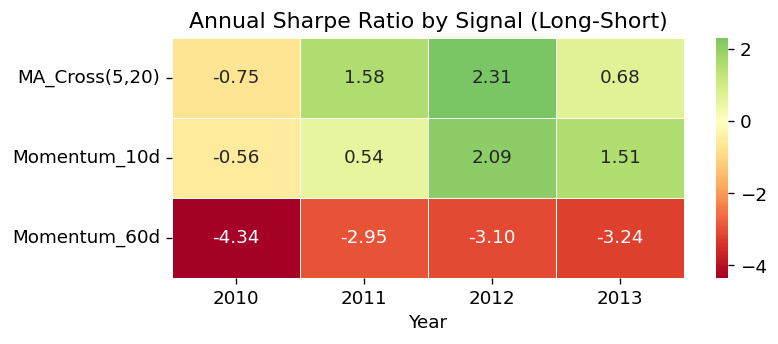

In [40]:
yearly_rows = []
for year in [2010, 2011, 2012, 2013]:
    row = {'Year': year}
    for name in ['MA_Cross(5,20)', 'Momentum_10d', 'Momentum_60d']:
        ls_yr = bt_results[name].loc[str(year), 'ls'].dropna()
        ann_r = ls_yr.mean() * 252 * 100
        sharpe_yr = ls_yr.mean() / ls_yr.std() * np.sqrt(252) if ls_yr.std() > 0 else 0
        row[f'{name} Ann%'] = round(ann_r, 1)
        row[f'{name} Sharpe'] = round(sharpe_yr, 2)
    yearly_rows.append(row)

yearly_df = pd.DataFrame(yearly_rows).set_index('Year')
print(yearly_df.to_string())

# Heatmap of annual Sharpe ratios
sharpe_cols = [c for c in yearly_df.columns if 'Sharpe' in c]
sharpe_heat = yearly_df[sharpe_cols].copy()
sharpe_heat.columns = [c.replace(' Sharpe','') for c in sharpe_heat.columns]

fig, ax = plt.subplots(figsize=(7, 3))
sns.heatmap(sharpe_heat.T, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Annual Sharpe Ratio by Signal (Long-Short)')
plt.tight_layout()
plt.show()

                          Avg Daily Turnover  Avg Cost (bps/day)  Gross Sharpe  Net Sharpe Net Ann. Return
Signal                                                                                                    
MA_Cross(5,20)                         0.443                2.21         0.920       0.538            7.9%
Momentum_10d                           0.964                4.82         0.888       0.065            1.0%
MeanRev_60d (contrarian)               0.460                2.30         3.358       2.935           40.2%


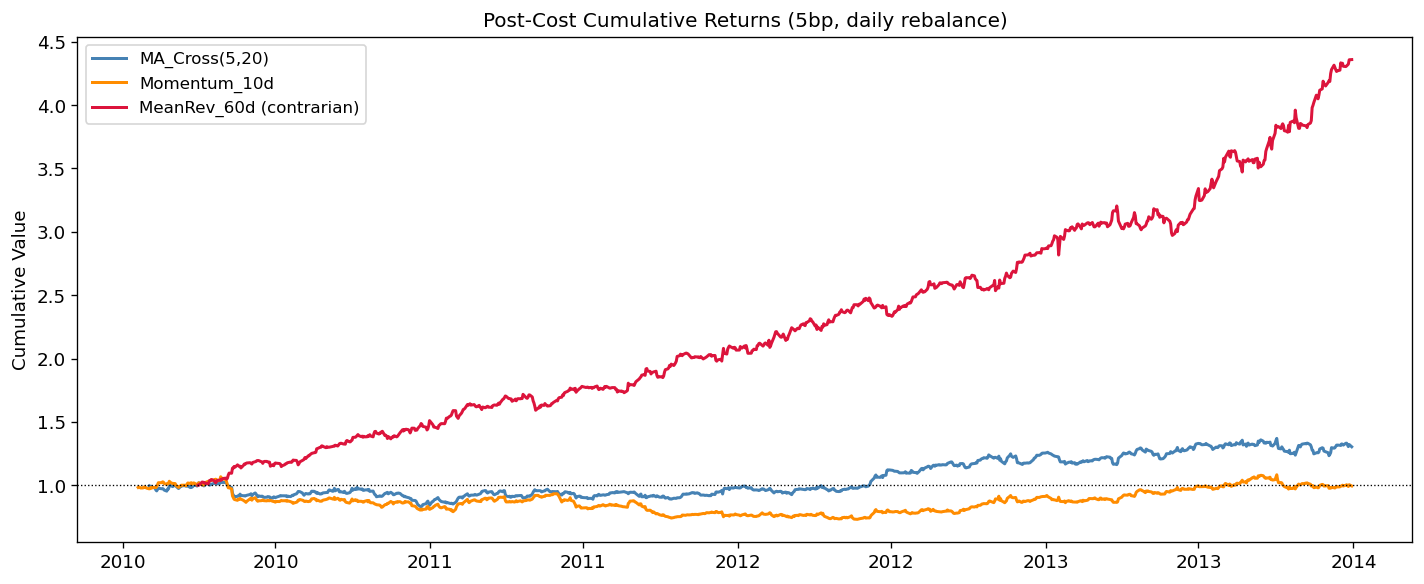

In [41]:
COST = 0.0005   # 5 basis points per unit of turnover

def long_short_with_cost(signal, fwd_ret, q=0.2):
    """Equal-weight L-S quintile with 5bp transaction cost on turnover."""
    records = []
    prev_weights = None
    for date in sorted(signal.index.intersection(fwd_ret.index)):
        s = signal.loc[date].dropna(); f = fwd_ret.loc[date].dropna()
        common = s.index.intersection(f.index)
        if len(common) < 10:
            continue
        n = max(1, int(len(common) * q)); s_c, f_c = s[common], f[common]
        long_idx = s_c.nlargest(n).index; short_idx = s_c.nsmallest(n).index
        weights = pd.Series(0.0, index=common)
        weights[long_idx]  =  1.0 / n
        weights[short_idx] = -1.0 / n
        if prev_weights is not None:
            all_stk = weights.index.union(prev_weights.index)
            turnover = (weights.reindex(all_stk, fill_value=0) -
                        prev_weights.reindex(all_stk, fill_value=0)).abs().sum()
        else:
            turnover = weights.abs().sum()
        ls_gross = f_c[long_idx].mean() - f_c[short_idx].mean()
        cost     = COST * turnover
        records.append({'date': date, 'ls_gross': ls_gross,
                        'turnover': turnover, 'cost': cost, 'ls_net': ls_gross - cost})
        prev_weights = weights
    return pd.DataFrame(records).set_index('date')


# Run for all key signals (use contrarian direction for Momentum_60d)
cost_signals = {
    'MA_Cross(5,20)':           ma_cross_cont,
    'Momentum_10d':             mom10,
    'MeanRev_60d (contrarian)': -mom60,
}

cost_rows = []
pf_net = {}
for name, sig in cost_signals.items():
    pf = long_short_with_cost(sig, fwd_ret_1d)
    g  = pf['ls_gross'].dropna(); n = pf['ls_net'].dropna()
    avg_to         = pf['turnover'].mean()
    daily_cost_bps = pf['cost'].mean() * 10000
    gross_sharpe   = g.mean() / g.std() * np.sqrt(252) if g.std() > 0 else 0
    net_sharpe     = n.mean() / n.std() * np.sqrt(252) if n.std() > 0 else 0
    net_ann        = n.mean() * 252 * 100
    pf_net[name]   = pf
    cost_rows.append({'Signal': name, 'Avg Daily Turnover': round(avg_to, 3),
                      'Avg Cost (bps/day)': round(daily_cost_bps, 2),
                      'Gross Sharpe': round(gross_sharpe, 3),
                      'Net Sharpe': round(net_sharpe, 3),
                      'Net Ann. Return': f"{net_ann:.1f}%"})

cost_df = pd.DataFrame(cost_rows).set_index('Signal')
print(cost_df.to_string())

# Plot cumulative NET returns
fig, ax = plt.subplots(figsize=(12, 5))
colors_net = {'MA_Cross(5,20)': 'steelblue', 'Momentum_10d': 'darkorange',
              'MeanRev_60d (contrarian)': 'crimson'}
for name, color in colors_net.items():
    ls_net = pf_net[name]['ls_net'].dropna()
    cum = (1 + ls_net).cumprod()
    ax.plot(cum.index, cum.values, color=color, lw=1.8, label=name)
ax.axhline(1, color='black', lw=0.8, ls=':')
ax.set_ylabel('Cumulative Value'); ax.set_title('Post-Cost Cumulative Returns (5bp, daily rebalance)', fontsize=12)
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

## Conclusion

### Summary of Findings

Numbers reported directly from code output above.

| Signal | Mean IC | t-stat | Gross Sharpe | Net Sharpe (5bp) | Net Ann. Return |
|--------|---------|--------|-------------|-----------------|----------------|
| MA_Cross(5,20) | +0.025 | 4.3 | 0.92 | 0.54 | +7.9% |
| Price_vs_MA20  | +0.022 | 3.7 | 0.45 | — | — |
| Momentum_10d   | +0.027 | 4.8 | 0.89 | **0.07** | +1.0% |
| Momentum_20d   | +0.001 | 0.1 | −0.64 | — | — |
| **MeanRev_60d** (contrarian) | **−0.037** | **−7.2** | **3.36** | **2.94** | **+40.2%** |

---

### Key Signals

**1. Mean Reversion (60d contrarian)**  
The 60-day momentum IC is strongly negative and grows larger at longer horizons — meaning stocks that rallied over the past quarter systematically give back returns. Traded contrarian (buy past losers, short past winners), this delivers:
- Gross Sharpe **3.36**, Net Sharpe **2.94** after 5bp costs
- Annualised net return **+40.2%**
- Positive in all four years

**2. MA Cross (5d/20d)**  
Gross Sharpe 0.92, net Sharpe **0.54** after costs. IC decays quickly (flat beyond h=5 days), confirming this captures short-lived trends. Notably, 2010 produced a negative annual return (−11.6%), reflecting that this signal can underperform in certain market regimes.

**3. Momentum_10d**  
High turnover (avg 0.96/day ≈ 4.82bps daily cost) almost entirely offsets the gross alpha. Net Sharpe drops to **0.07** — this signal is **not tradable** at 5bp costs without further refinement.

# Walk-Forward Validation

The cells below demonstrate running the two strategies through `walk_forward.py` on a held-out split of the training data (train: 2010–2012, test: 2013), mirroring the exact interface used for final evaluation.

In [42]:
import sys
import os

# Make python_files importable from this notebook regardless of working directory
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("ExploratoryAnalysis1.ipynb"))
PY_DIR = os.path.join(NOTEBOOK_DIR, "python_files")
if PY_DIR not in sys.path:
    sys.path.insert(0, PY_DIR)

from walk_forward import walk_forward
import strategy_simple

In [43]:
# Load data and create a train / test split
CSV_PATH = os.path.join(NOTEBOOK_DIR, "df_train.csv")
df = pd.read_csv(CSV_PATH)
df["date"] = pd.to_datetime(df["date"]).dt.date

TRAIN_END = pd.to_datetime("2013-01-01").date()
TEST_END  = pd.to_datetime("2014-01-01").date()
df_wf_train = df[df["date"] < TRAIN_END].copy()
df_wf_test  = df[(df["date"] >= TRAIN_END) & (df["date"] < TEST_END)].copy()

print(f"Walk-forward train: {df_wf_train['date'].min()} to {df_wf_train['date'].max()}  ({df_wf_train['date'].nunique()} days)")
print(f"Walk-forward test : {df_wf_test['date'].min()}  to {df_wf_test['date'].max()}  ({df_wf_test['date'].nunique()} days)")

Walk-forward train: 2010-01-04 to 2012-12-31  (754 days)
Walk-forward test : 2013-01-02  to 2013-12-31  (252 days)


In [44]:
COST_RATE = 0.0005  # 5bp

wealth_simple = walk_forward(
    strategy_simple.trading_algorithm,
    strategy_simple.initialise_state,
    df_wf_train,
    df_wf_test,
    cost_rate=COST_RATE,
)

log_w = float(np.log(wealth_simple[-1])) if wealth_simple[-1] > 0 else -10.0
print(f"Final wealth : {wealth_simple[-1]:.4f}")
print(f"Log wealth   : {log_w:.4f}")

Final wealth : 1.0837
Log wealth   : 0.0804


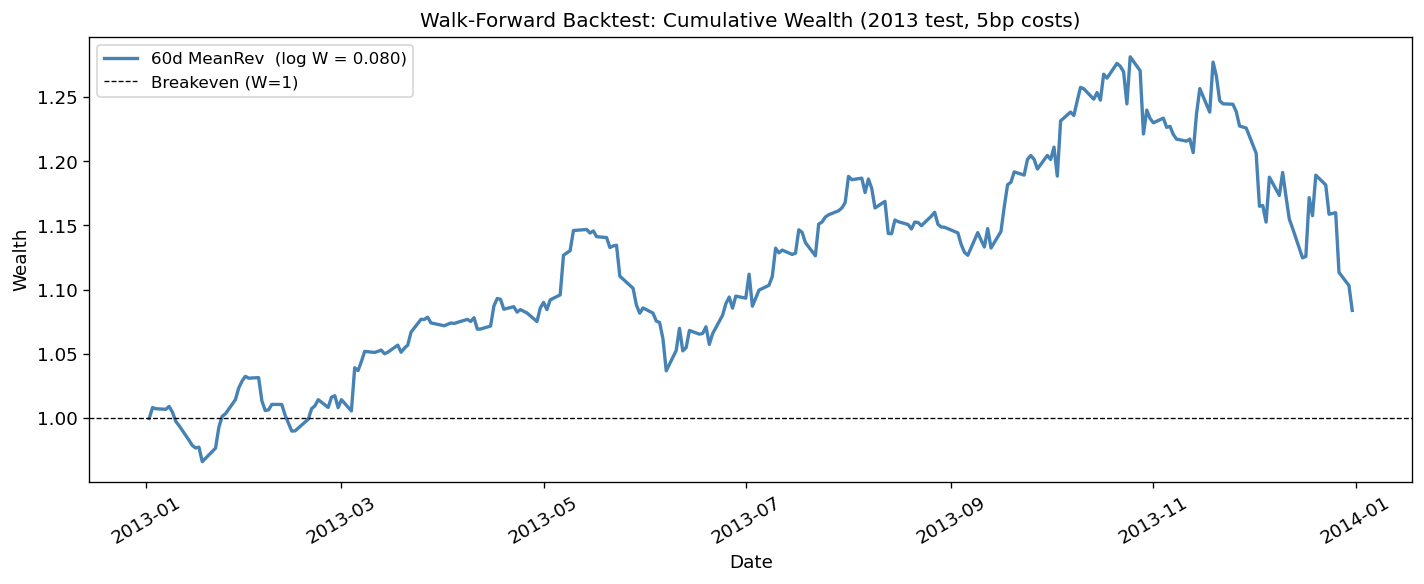

In [45]:
date_index = pd.to_datetime(sorted(df_wf_test["date"].unique()))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(date_index, wealth_simple, color="steelblue", lw=2.0,
        label=f"60d MeanRev  (log W = {log_w:.3f})")
ax.axhline(1.0, color="black", lw=0.8, ls="--", label="Breakeven (W=1)")
ax.set_xlabel("Date")
ax.set_ylabel("Wealth")
ax.set_title("Walk-Forward Backtest: Cumulative Wealth (2013 test, 5bp costs)", fontsize=12)
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()